In [1]:
"""
Comprehensive TGF-beta pathway analysis figure for publication
Multi-panel figure showing TGFB1, TGFB2, TGFBI expression across immune cells
Plus statistical comparisons and supporting analyses
"""

import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import scanpy as sc
from scipy import sparse
from scipy.stats import mannwhitneyu, kruskal
from statsmodels.stats.multitest import multipletests


In [ ]:

# Define paths
data_dir = Path(r'T:\Analysis\116_MDACC_Chiba\chiba\adatas_with_rctd')
output_dir = Path(r'T:\Analysis\116_MDACC_Chiba\tgfb_pathway_figure')
output_dir.mkdir(exist_ok=True)

print("="*80)
print("COMPREHENSIVE TGF-BETA PATHWAY ANALYSIS")
print("="*80)


COMPREHENSIVE TGF-BETA PATHWAY ANALYSIS


In [3]:

# Load all GBM samples
gbm_files = sorted(data_dir.glob('adata_GBM*_with_rctd.h5ad'))
print(f"\nLoading {len(gbm_files)} GBM samples...")

adatas = []
for f in gbm_files:
    adata_temp = ad.read_h5ad(f)
    adata_temp.obs['sample'] = f.name.replace('adata_', '').replace('_with_rctd.h5ad', '')
    adatas.append(adata_temp)

adata_all = ad.concat(adatas, join='outer', index_unique='_')
print(f"Total cells: {adata_all.n_obs:,}")

# Define immune cell types
immune_celltypes = [
    'TAM-MG', 'TAM-BDM', 'Mono', 'DC', 'Neutrophil',
    'Mast', 'NK', 'B cell', 'Plasma B'
]

# Filter for immune cells
immune_mask = adata_all.obs['rctd_cell_type'].isin(immune_celltypes)
adata_immune = adata_all[immune_mask].copy()
print(f"Immune cells: {adata_immune.n_obs:,}")

# Filter to well-represented cell types
min_cells = 5
celltype_counts = adata_immune.obs['rctd_cell_type'].value_counts()
valid_celltypes = celltype_counts[celltype_counts >= min_cells].index.tolist()
adata_immune = adata_immune[adata_immune.obs['rctd_cell_type'].isin(valid_celltypes)].copy()

print(f"\nCell type distribution:")
print(adata_immune.obs['rctd_cell_type'].value_counts())

# Normalize
if 'X_normalized' not in adata_immune.layers:
    print("\nNormalizing data...")
    adata_immune.layers['counts'] = adata_immune.X.copy()
    sc.pp.normalize_total(adata_immune, target_sum=1e4)
    sc.pp.log1p(adata_immune)

# TGF-beta genes
tgfb_genes = ['TGFB1', 'TGFB2', 'TGFBI']

# Extract expression data for each gene
print("\nExtracting expression data...")
expr_dict = {}
for gene in tgfb_genes:
    if gene in adata_immune.var_names:
        gene_idx = adata_immune.var_names.tolist().index(gene)
        if sparse.issparse(adata_immune.X):
            expr_dict[gene] = adata_immune.X[:, gene_idx].toarray().flatten()
        else:
            expr_dict[gene] = adata_immune.X[:, gene_idx].flatten()

# Add to obs
for gene, expr in expr_dict.items():
    adata_immune.obs[f'{gene}_expr'] = expr
    adata_immune.obs[f'{gene}_positive'] = expr > 0

# Calculate statistics
print("\nCalculating statistics...")
stats_data = []

for celltype in valid_celltypes:
    ct_mask = adata_immune.obs['rctd_cell_type'] == celltype
    n_cells = ct_mask.sum()

    for gene in tgfb_genes:
        if gene in expr_dict:
            expr_vals = expr_dict[gene][ct_mask]

            stats_data.append({
                'Cell Type': celltype,
                'Gene': gene,
                'N Cells': n_cells,
                'Mean Expression': np.mean(expr_vals),
                'Median Expression': np.median(expr_vals),
                'Std Expression': np.std(expr_vals),
                'Percent Expressing': (expr_vals > 0).sum() / len(expr_vals) * 100,
                'N Expressing': (expr_vals > 0).sum(),
                'Mean (Expressing Only)': np.mean(expr_vals[expr_vals > 0]) if (expr_vals > 0).any() else 0
            })

df_stats = pd.DataFrame(stats_data)
df_stats.to_csv(output_dir / 'tgfb_expression_statistics.csv', index=False)

# Perform statistical comparisons
print("\nPerforming statistical comparisons...")

# Compare each cell type to all others for each gene
comparison_results = []

for gene in tgfb_genes:
    if gene in expr_dict:
        for celltype in valid_celltypes:
            ct_mask = adata_immune.obs['rctd_cell_type'] == celltype
            other_mask = ~ct_mask

            ct_expr = expr_dict[gene][ct_mask]
            other_expr = expr_dict[gene][other_mask]

            # Mann-Whitney U test
            statistic, pvalue = mannwhitneyu(ct_expr, other_expr, alternative='two-sided')

            comparison_results.append({
                'Gene': gene,
                'Cell Type': celltype,
                'Comparison': f'{celltype} vs All Others',
                'N_CellType': len(ct_expr),
                'N_Others': len(other_expr),
                'Mean_CellType': np.mean(ct_expr),
                'Mean_Others': np.mean(other_expr),
                'Median_CellType': np.median(ct_expr),
                'Median_Others': np.median(other_expr),
                'U_statistic': statistic,
                'P_value': pvalue
            })

df_comparisons = pd.DataFrame(comparison_results)

# Apply multiple testing correction
for gene in tgfb_genes:
    gene_mask = df_comparisons['Gene'] == gene
    pvals = df_comparisons.loc[gene_mask, 'P_value'].values
    _, pvals_adj, _, _ = multipletests(pvals, method='fdr_bh')
    df_comparisons.loc[gene_mask, 'P_value_adj_BH'] = pvals_adj

df_comparisons['Significant_BH'] = df_comparisons['P_value_adj_BH'] < 0.05
df_comparisons.to_csv(output_dir / 'tgfb_statistical_comparisons.csv', index=False)

print(f"\nSignificant comparisons (FDR < 0.05):")
print(df_comparisons[df_comparisons['Significant_BH']][['Gene', 'Cell Type', 'Mean_CellType', 'Mean_Others', 'P_value_adj_BH']])



Loading 20 GBM samples...
Total cells: 91,325
Immune cells: 1,219

Cell type distribution:
rctd_cell_type
TAM-MG        716
TAM-BDM       124
Neutrophil    122
Mono          101
Plasma B       56
DC             35
Mast           32
B cell         26
NK              7
Name: count, dtype: int64

Normalizing data...

Extracting expression data...

Calculating statistics...

Performing statistical comparisons...

Significant comparisons (FDR < 0.05):
     Gene   Cell Type  Mean_CellType  Mean_Others  P_value_adj_BH
0   TGFB1      TAM-MG       2.998991     1.622063    5.273495e-15
2   TGFB1  Neutrophil       1.322055     2.554133    1.217965e-04
4   TGFB1    Plasma B       0.265514     2.535087    8.887680e-10
6   TGFB1        Mast       1.096430     2.466798    2.367261e-02
7   TGFB1      B cell       1.037327     2.461194    1.730395e-02
9   TGFB2      TAM-MG       1.934693     0.721231    5.342709e-21
10  TGFB2     TAM-BDM       1.876447     1.383872    1.669050e-02
11  TGFB2  Neutrophi


Generating main figure...


[Text(0.5, 0, 'TGFB1'), Text(1.5, 0, 'TGFB2'), Text(2.5, 0, 'TGFBI')]

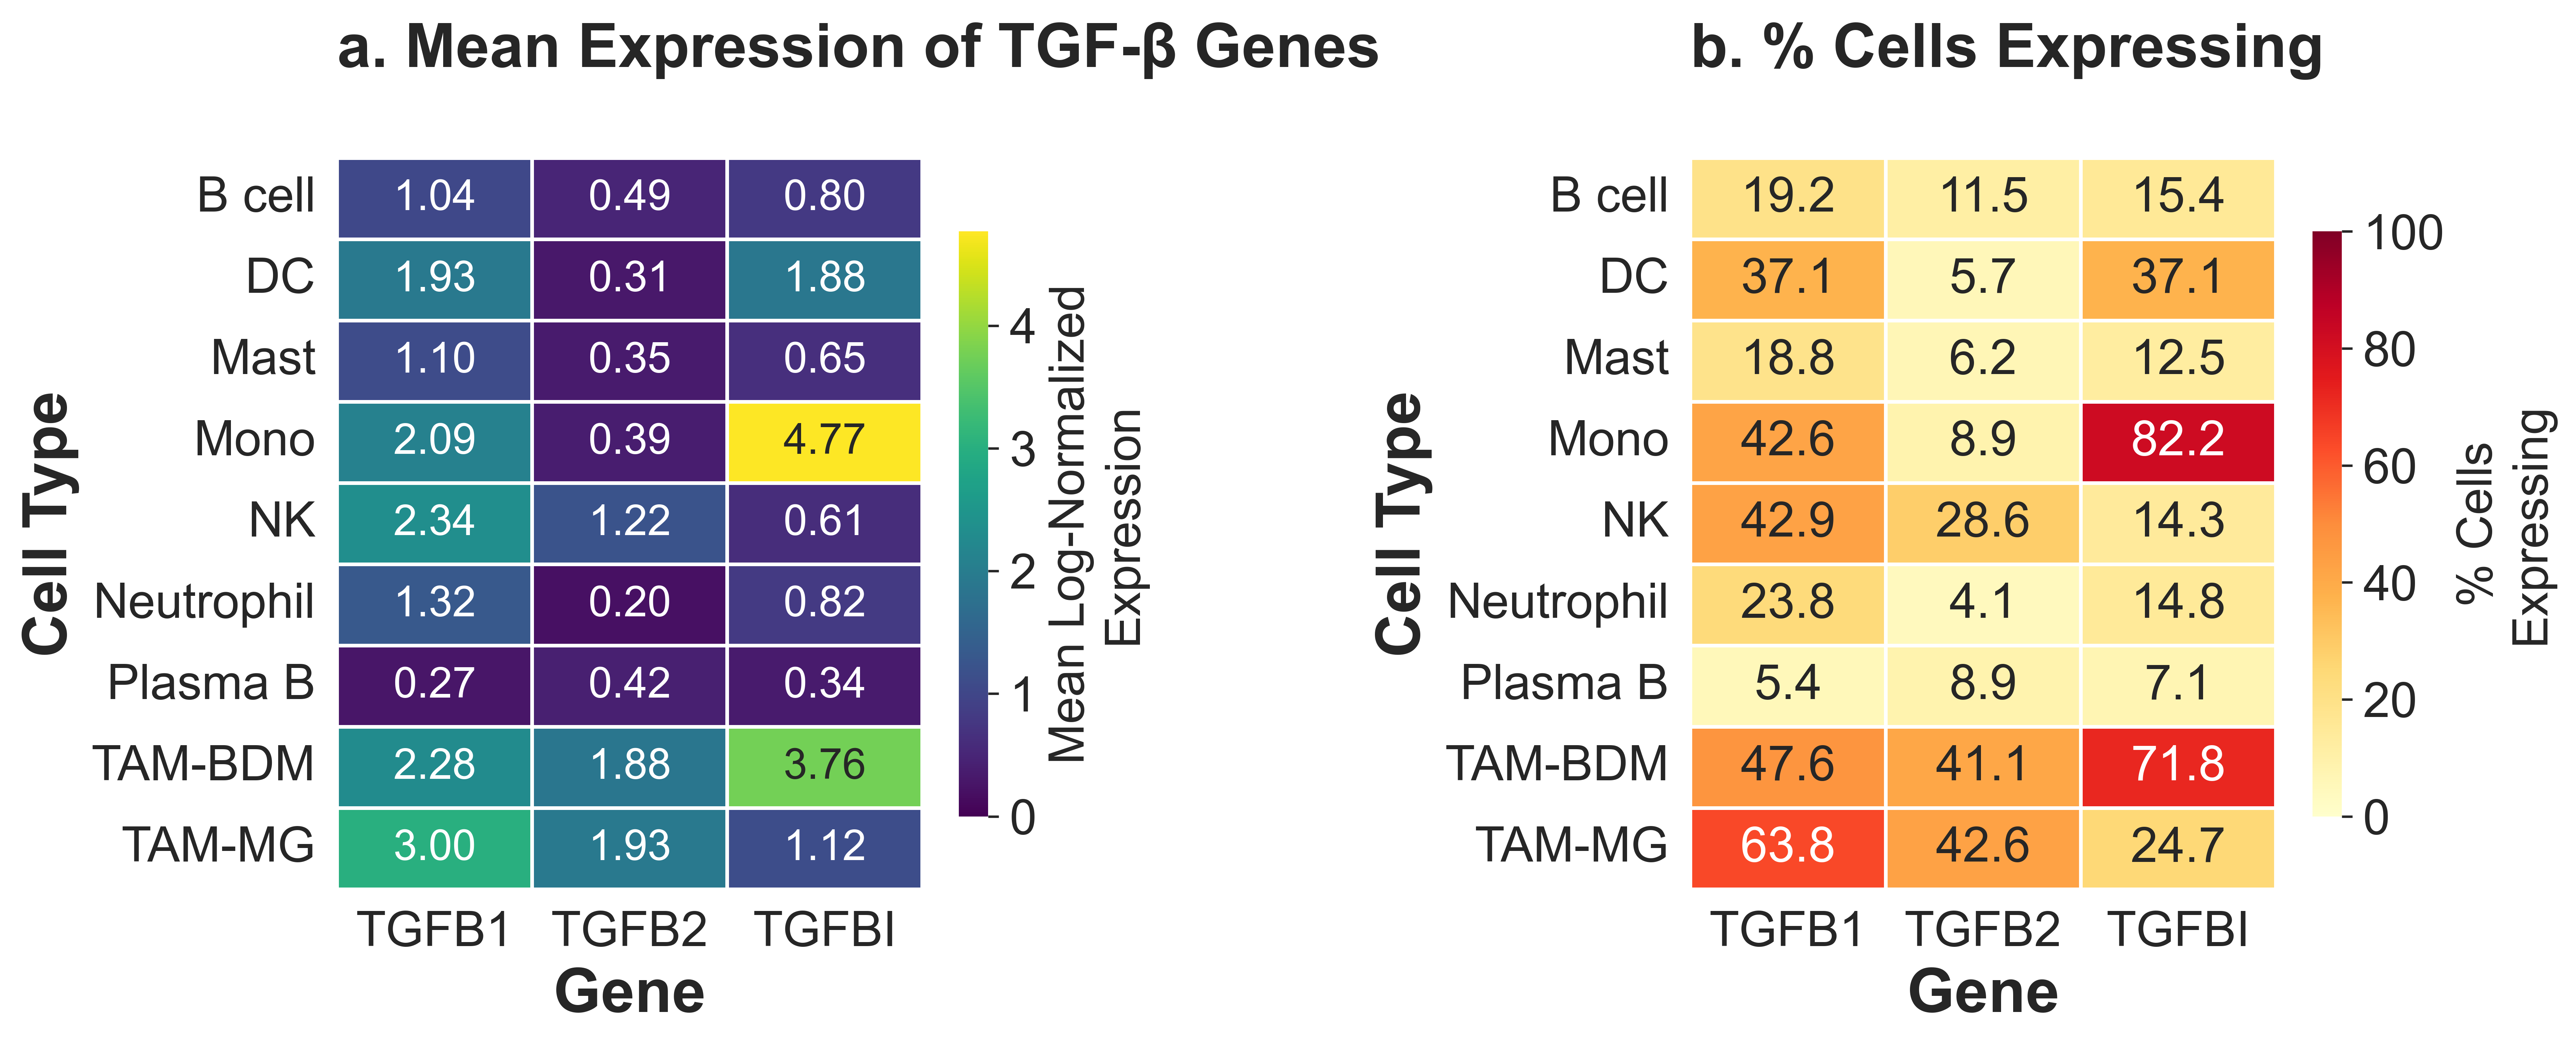

In [ ]:

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 600
plt.rcParams['font.size'] = 16
plt.rcParams['font.family'] = 'Arial'

# ============================================================================
# MAIN FIGURE: Multi-panel comprehensive TGF-beta analysis
# ============================================================================
print("\nGenerating main figure...")

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.85,
                      left=0.08, right=0.95, top=0.94, bottom=0.06)

# Color palette for cell types
celltype_colors = {
    'TAM-MG': '#1f77b4',
    'TAM-BDM': '#ff7f0e',
    'Mono': '#2ca02c',
    'DC': '#d62728',
    'Neutrophil': '#9467bd',
    'Mast': '#8c564b',
    'NK': '#e377c2',
    'B cell': '#7f7f7f',
    'Plasma B': '#bcbd22'
}


# ============================================================================
# PANEL A: Mean expression heatmap
# ============================================================================
ax_a = fig.add_subplot(gs[0, 0])

df_mean_pivot = df_stats.pivot(index='Cell Type', columns='Gene', values='Mean Expression')
df_mean_pivot = df_mean_pivot[tgfb_genes]  # Ensure correct order

sns.heatmap(df_mean_pivot,
            cmap='viridis',
            annot=True,
            fmt='.2f',
            cbar_kws={'label': 'Mean Log-Normalized\nExpression', 'shrink': 0.8},
            linewidths=1,
            linecolor='white',
            ax=ax_a,
            annot_kws={'fontsize': 14},
            vmin=0,
            vmax=df_mean_pivot.max().max())

ax_a.set_title('a. Mean Expression of TGF-β Genes',
               fontsize=20, fontweight='bold', loc='left', pad=30)
ax_a.set_xlabel('Gene', fontsize=20, fontweight='bold')
ax_a.set_ylabel('Cell Type', fontsize=20, fontweight='bold')
ax_a.set_xticklabels(ax_a.get_xticklabels(), rotation=0)
ax_a.set_yticklabels(ax_a.get_yticklabels(), rotation=0)

# ============================================================================
# PANEL B: Percent expressing heatmap
# ============================================================================
ax_b = fig.add_subplot(gs[0, 1])

df_pct_pivot = df_stats.pivot(index='Cell Type', columns='Gene', values='Percent Expressing')
df_pct_pivot = df_pct_pivot[tgfb_genes]

sns.heatmap(df_pct_pivot,
            cmap='YlOrRd',
            annot=True,
            fmt='.1f',
            cbar_kws={'label': '% Cells\nExpressing', 'shrink': 0.8},
            linewidths=1,
            linecolor='white',
            ax=ax_b,
            vmin=0,
            vmax=100)

ax_b.set_title('b. % Cells Expressing',
               fontsize=20, fontweight='bold', loc='left', pad=30)
ax_b.set_xlabel('Gene', fontsize=20, fontweight='bold')
ax_b.set_ylabel('Cell Type', fontsize=20, fontweight='bold')
ax_b.set_yticklabels(ax_b.get_yticklabels(), rotation=0)
ax_b.set_xticklabels(ax_b.get_xticklabels(), rotation=0)


